# Cifar-10 CNN

In [16]:
import keras
from keras import layers

import tensorflow as tf
from tensorflow.keras.datasets import cifar10

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix
import seaborn as sns

import warnings

warnings.filterwarnings(
    "ignore",
    message=".*align should be passed as Python or NumPy boolean.*"
)

## Data Preparation

The preprocessing of the data is done the same way it was done with FCN model to ensure comparable results. In short, the data is loaded into memory, labeled, normalized and one-hot encoded for the training and analysis.

In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

num_classes = 10

In [3]:
x_train, x_test = x_train / 255.0, x_test / 255.0

y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)


## Modeling

### Final model

After vigorous testing of different neural networks, the following was found to be the most effective. It consists of a three convolution blocks. Each block contains two 2D convolution layers, each immediately followed by batch normalization to stabilize training. After the pair of convolutions, the feature maps are downsampled using max pooling, and 25% of the activations are randomly dropped during training to reduce overfitting. Each convolution block features an increasing number of filters, allowing the network to learn progressively more complex and abstract features at deeper layers. It should be noted that because the input resolution of 32×32 is relatively small and the network contains many convolution layers, each convolution is padded to preserve the spatial dimensions. Without padding, the feature maps would shrink too quickly, limiting the depth of the model significantly. 

After the convolution blocks, the resulting feature maps are flattened and passed into a final dense layer consisting of 128 fully connected neurons. This layer serves as the model’s high‑level decision stage, integrating the abstract features extracted by the convolutional layers into a compact representation suitable for classification. After this the output layer uses softmax to extract class propabilities for the CIFAR-10 classes.

Summary of the final network is shown below. The final model has 550 000 trainable parameters.

In [4]:
input_shape = (32, 32, 3)

inputs = keras.Input(shape=input_shape)

x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(pool_size=(2, 2))(x)
x = layers.Dropout(0.25)(x)

x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(pool_size=(2, 2))(x)
x = layers.Dropout(0.25)(x)

x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(pool_size=(2, 2))(x)
x = layers.Dropout(0.25)(x)

x = layers.Flatten()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.25)(x)

outputs = layers.Dense(10, activation='softmax')(x)

model = keras.Model(inputs=inputs, outputs=outputs)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             

 Total params: 552,362 (2.11 MB)

 Trainable params: 551,466 (2.10 MB)

 Non-trainable params: 896 (3.50 KB)

After the construction of the model it is combiled using as the FCN model was using Adam as the optimizer and categorical crossentropy as the loss function. Notably Adams learning rate is not tweaked since it was found not to provide addition benefit when training this model.

In [5]:
optimizer = keras.optimizers.Adam()
loss = keras.losses.CategoricalCrossentropy()

model.compile(
    optimizer=optimizer,
    loss=loss,
    metrics=["accuracy"]
)

A batch size of 32 was ultimately selected, as it was found to produce a stable and consistent learning curve during experimentation. Through testing, 18 epochs were identified as the optimal training duration, providing a balance between sufficient learning and avoiding overfitting. Additionally, 20% of the training data is reserved validation.

In [6]:
history = model.fit(x_train, y_train, batch_size=32, epochs=18, validation_split=0.2)

Epoch 1/18
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 43s 31ms/step - accuracy: 0.4331 - loss: 1.5810 - val_accuracy: 0.5534 - val_loss: 1.2770
Epoch 2/18
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 39s 31ms/step - accuracy: 0.5991 - loss: 1.1426 - val_accuracy: 0.5587 - val_loss: 1.2455
Epoch 3/18
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 39s 31ms/step - accuracy: 0.6660 - loss: 0.9591 - val_accuracy: 0.6685 - val_loss: 0.9365
Epoch 4/18
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 40s 32ms/step - accuracy: 0.7085 - loss: 0.8517 - val_accuracy: 0.6970 - val_loss: 0.8774
Epoch 5/18
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 39s 31ms/step - accuracy: 0.7345 - loss: 0.7694 - val_accuracy: 0.7498 - val_loss: 0.7519
Epoch 6/18
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 39s 31ms/step - accuracy: 0.7577 - loss: 0.7023 - val_accuracy: 0.7789 - val_loss: 0.6489
Epoch 7/18
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 39s 32ms/step - accuracy: 0.7788 - loss: 0.6501 - val_accuracy: 0.7735 - val_loss: 0.6810
Epoch 8/18
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 39s 32ms/step - accuracy: 0.7939 -

### Tested improvements

#### Structure
Different model structures were explored during the development process. The blockbased architecture quickly emerged as the superior choice, and subsequent experimentation focused on refining this structure. Various numbers of blocks were tested, along with different configurations of filters and convolution layers. The siphonlike design, featuring two convolution layers per block proved to be the most effective, offering strong performance without introducing unnecessary complexity that could lead to overfitting.

#### Regularization
Different regularization methods and combinations of these methods were tested. In the end, normalizing the activations after each convolution layer made the model significantly more stable and easier to train. Adding dropout after each block inturn reduced the models tendency to overfit. A dropout rate of 25% proved to be the optimal balance. High enough to prevent overfitting, yet low enough to allow the network to learn effectively.

#### Data augmentation
Since data augmentation was found to introduce excessive noise during the development of the fully connected network, it was not attempted with the convolutional neural network model.

## Evaluation

The loss and accuracy values for both the training and validation sets are recorded at each epoch and plotted to allow for visual assessment of the model’s learning behavior.

As shown in both graphs, the validation curve neatly follows the training curve, indicating that the model does not overfit. Training is continued until the validation loss starts to plateau, indicating that the model has reached its limit. At this point, learning is stopped and the model is considered ready for evaluation.

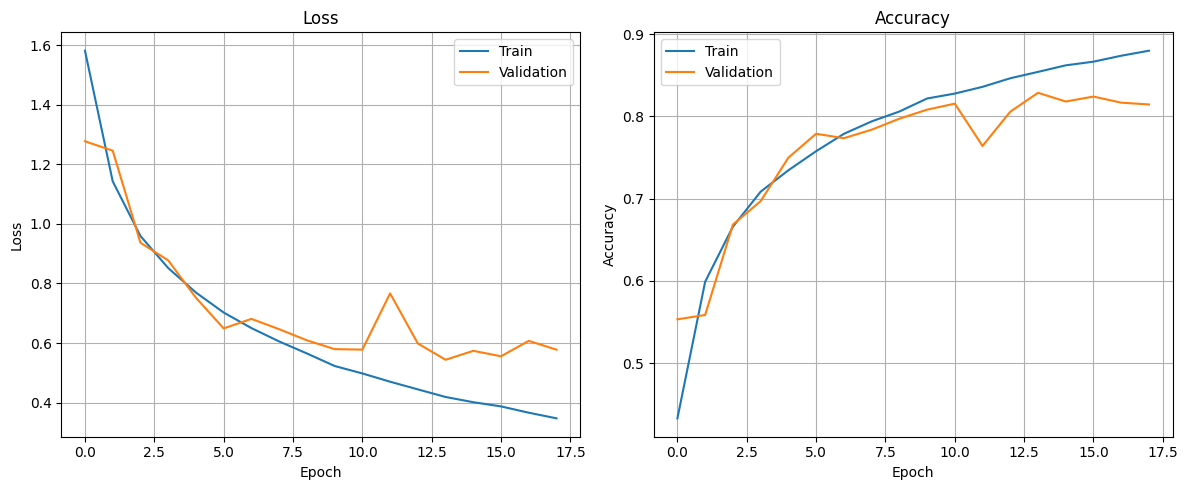

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(history.history["loss"])
ax[0].plot(history.history["val_loss"])
ax[0].set_title("Loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].legend(["Train", "Validation"])
ax[0].grid()

ax[1].plot(history.history["accuracy"])
ax[1].plot(history.history["val_accuracy"])
ax[1].set_title("Accuracy")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].legend(["Train", "Validation"])
ax[1].grid()

plt.tight_layout()
plt.show()

The complete model is then evaluated using the test dataset that was set aside at the beginning. The final accuracy achieved on the test set is 81%, which is a clear improvement over the fully connected networks tested earlier. This result demonstrates the effectiveness of convolutional feature extraction and confirms that the chosen model structure is able to strike a balance between model complexity and generalization. Since the CIFAR-10 images are relatively small and contain only coarse visual details, achieving stronger performance without overfitting would be difficult, but not entirely impossible.

In [8]:
test_scores = model.evaluate(x_test, y_test, verbose=2)
print("Test loss:", test_scores[0])
print("Test accuracy:", test_scores[1])

313/313 - 3s - 9ms/step - accuracy: 0.8101 - loss: 0.6029
Test loss: 0.6028500199317932
Test accuracy: 0.8101000189781189


To visualize the performance of the final model more clearly, a confusion matrix is used. It shows that, similar to the fully connected model, this network still has the most difficulty distinguishing between the cat and dog classes. Overall however, the convolutional neural network achieves noticeably stronger performance, which is consistent with the accuracy metric. Unlike the fully connected model, this architecture even includes class pairs for which it makes no mistakes at all. This result confirms the hypothesis that using a convolutional neural network to process image data provides a significant advantage, as the convolutional layers are able to extract spatial and structural features that fully connected layers cannot capture effectively.

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


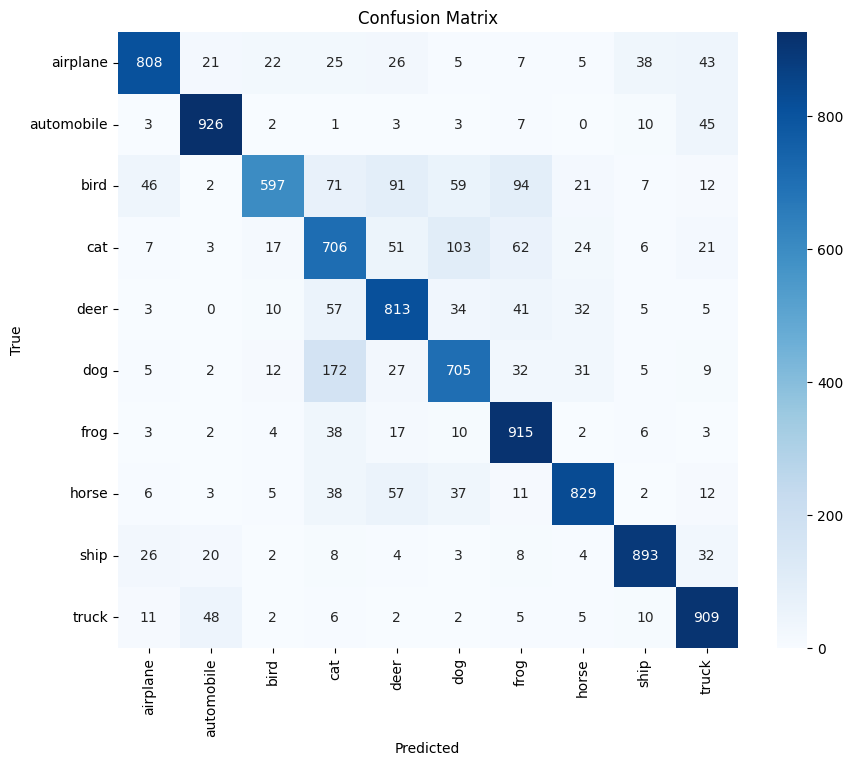

In [9]:
y_pred = model.predict(x_test)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

A bar chart further confirms that the model struggles the most with the cat class, achieving only a modest 60% accuracy. For comparison, most of the other classes exceed 80% accuracy, with the frog and automobile classes even surpassing the 90% mark. This disparity highlights how certain categories in CIFAR‑10 are inherently more challenging due to visual similarity or higher intra‑class variation, while others contain more distinctive features that the model can reliably capture.

In [10]:
num_classes = 10
class_acc = []

for c in range(num_classes):
    idx = np.where(y_true_classes == c)[0]
    correct = np.sum(y_pred_classes[idx] == c)
    acc = correct / len(idx)
    class_acc.append(acc)

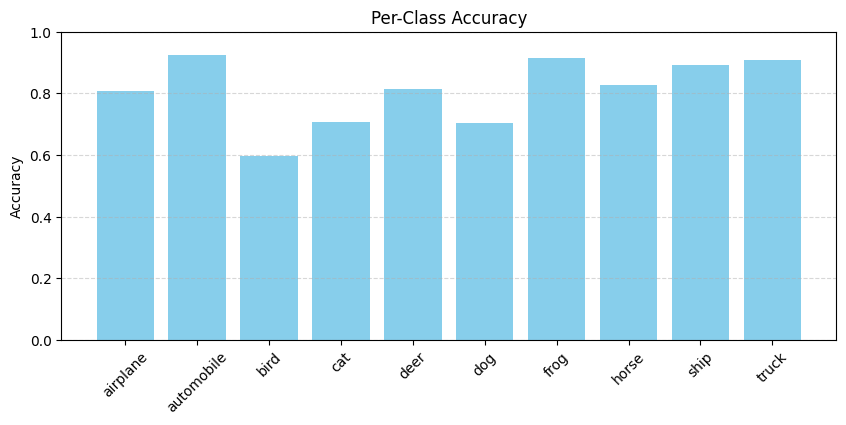

In [11]:
plt.figure(figsize=(10, 4))
plt.bar(class_names, class_acc, color="skyblue")
plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.title("Per-Class Accuracy")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

An additional examination of the model’s capability to distinguish between the superclasses vehicle and animal was also performed. This analysis shows that the model achieves very high accuracy at this broader classification level, reaching approximately 97%. This indicates that while the model may struggle with fine‑grained distinctions between visually similar classes (such as cats and dogs), it is highly reliable at high level separation. This separation capability emerges as a byproduct of the lower class‑level training, where the model learns features that naturally distinguish animals from vehicles even though it was never explicitly trained on the superclass labels.

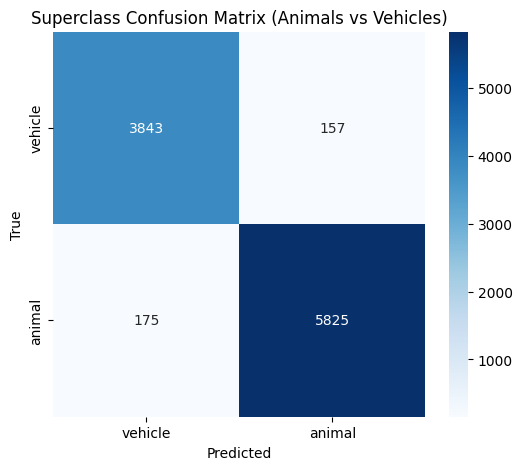

Accuracy: 96.68%


In [15]:
vehicles = {'airplane', 'automobile', 'ship', 'truck'}
animals = {'bird', 'cat', 'deer', 'dog', 'frog', 'horse'}

superclass_map = {}
for idx, name in enumerate(class_names):
    if name in vehicles:
        superclass_map[idx] = 0
    else:
        superclass_map[idx] = 1

y_pred_super = np.array([superclass_map[c] for c in y_pred_classes])
y_true_super = np.array([superclass_map[c] for c in y_true_classes])

cm_super = confusion_matrix(y_true_super, y_pred_super)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_super, annot=True, fmt="d", cmap="Blues",
            xticklabels=["vehicle", "animal"],
            yticklabels=["vehicle", "animal"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Superclass Confusion Matrix (Animals vs Vehicles)")
plt.show()

vehicle_correct = cm_super[0, 0]
vehicle_total = cm_super[0].sum()

animal_correct = cm_super[1, 1]
animal_total = cm_super[1].sum()

overall_acc = (vehicle_correct + animal_correct) / cm_super.sum() * 100

print(f"Accuracy: {overall_acc:.2f}%")

Below are sample images from the test set, each annotated with the true label and the model’s predicted label. As noted earlier, the low resolution of CIFAR‑10 images makes some samples challenging even for human observers.

Since the models accuracy is relatively high, it predicts most of the images in this image set correctly. Only three misclassifications occur, two of which happen within the vehicle superclass. The only mistake that crosses superclass boundaries is the first image in the third row, where the model incorrectly classifies an airplane as a cat. Although this type of error is rare, it is not entirely unexpected: the model consistently performs worst on the cat class, so it is not unlikely that even unusual misclassifications tend to involve it. For a human observer however, the image clearly depicts an aircraft, even if it appears slightly blurry due to the low resolution. 

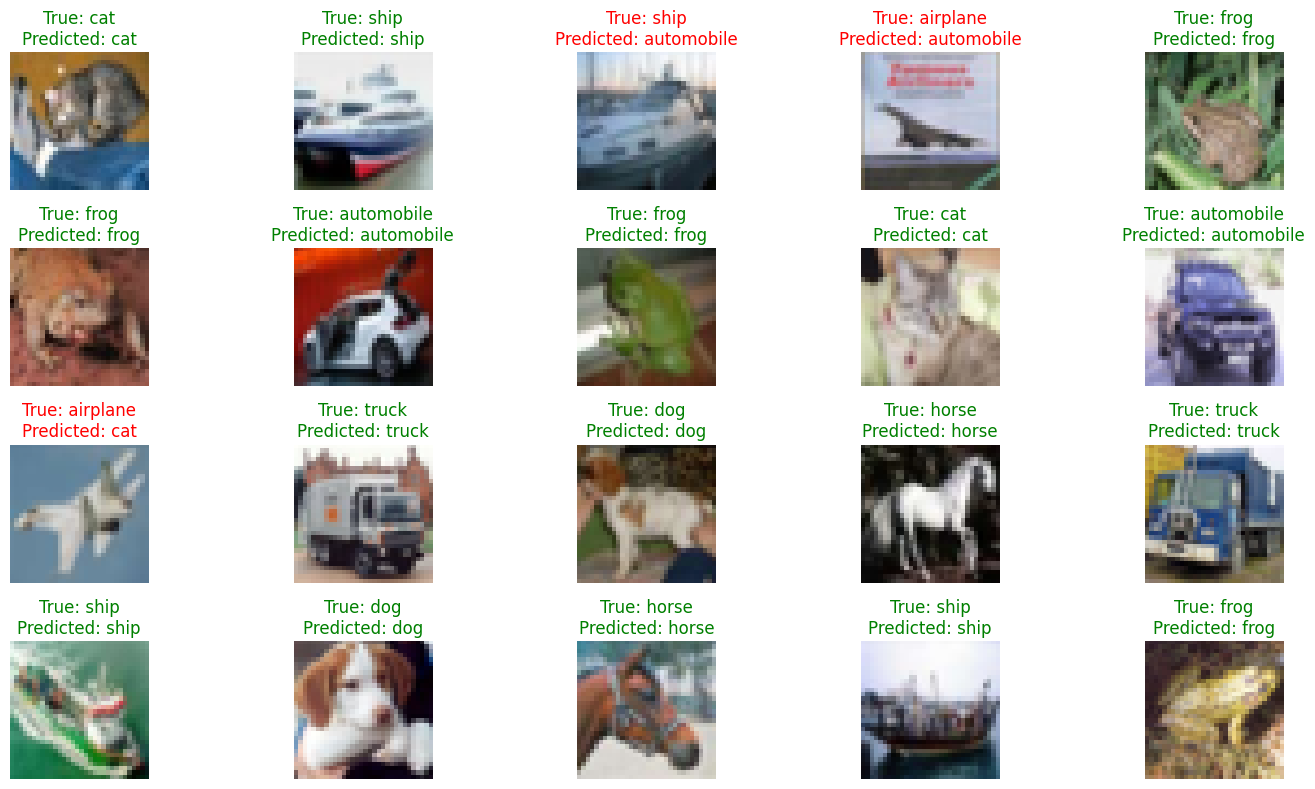

In [13]:
y_test = y_test.astype(int).flatten()

plt.figure(figsize=(15, 8))

for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(x_test[i])
    plt.axis("off")

    color = "green" if y_true_classes[i] == y_pred_classes[i] else "red"
    plt.title(f"True: {class_names[y_true_classes[i]]}\nPredicted: {class_names[y_pred_classes[i]]}", color=color)

plt.tight_layout()
plt.show()

All in all, this simple convolution neutral network is able to classify CIFAR‑10 images to a relatively high degree. The accuracy of the model is high, especially when using the model to distinguish between the superclasses of animal and vehicle.

A convolutional neural network provides exactly the level of complexity needed for this task. By processing images through convolutional layers, the model preserves the spatial structure of the data. Local pixel relationships, edges, patterns are all retained and analyzed directly within the feature maps. Instead of viewing an image as a flat list of numbers, the CNN interprets it as a structured visual scene, allowing it to learn meaningful representations at multiple levels of abstraction. This enables the network to recognize shapes and object parts far more effectively, which is crucial for distinguishing between visually similar classes in CIFAR‑10. 